# Lesson 7.4 — Resolved-Rate Motion (Open-Loop Velocity Layer)
**Module 6 · Unit 7 · Lesson 28**

The loop: ξ_d → q̇ = J⁺_λ(q) ξ_d → q ← q + q̇ Δt → recompute J → repeat. **Open-loop, kinematic.** Not trajectory generation (M7), not feedback control (M8).

In [1]:
import numpy as np
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i]); M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def Jv_planar(P,T,q): return geometric_jacobian(P,T,q)[:2,:]
def fk_xy(P,T,q):
    M=forward_chain(P,T,q)[-1]; return M[:2,3].copy()
def dls_inv(J,lam): return J.T@np.linalg.inv(J@J.T+lam**2*np.eye(J.shape[0]))
P2=[(0,0,1,0),(0,0,1,0)]; T2=["R","R"]
P3=[(0,0,1,0),(0,0,1,0),(0,0,0.6,0)]; T3=["R","R","R"]


## Resolved-rate loop tracks a commanded constant tool velocity (open-loop)

max open-loop drift over 60 steps: 0.00115


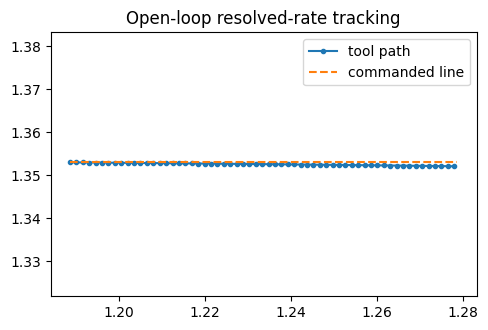

In [2]:
import matplotlib.pyplot as plt
checks=[]
def resolved_rate(P,T,q0,vd,dt,steps,lam=0.05):
    q=q0.copy(); pts=[fk_xy(P,T,q)]
    for _ in range(steps):
        J=Jv_planar(P,T,q); qd=dls_inv(J,lam)@vd; q=q+qd*dt; pts.append(fk_xy(P,T,q))
    return np.array(pts),q
q0=np.array([0.4,0.9]); vd=np.array([0.15,0.0]); dt=0.01; steps=60
pts,_=resolved_rate(P2,T2,q0,vd,dt,steps)
ideal=pts[0]+np.outer(np.arange(steps+1)*dt,vd)
drift=np.max(np.linalg.norm(pts-ideal,axis=1))
print("max open-loop drift over",steps,"steps:",round(drift,6))
checks.append(drift<1e-2)
plt.figure(figsize=(5,3.4)); plt.plot(pts[:,0],pts[:,1],'o-',ms=3,label='tool path'); plt.plot(ideal[:,0],ideal[:,1],'--',label='commanded line')
plt.axis('equal'); plt.legend(); plt.title('Open-loop resolved-rate tracking'); plt.tight_layout(); plt.show()

## Instantaneous tool velocity equals the command (full rank)

In [3]:
J=Jv_planar(P2,T2,q0); qd=np.linalg.pinv(J)@vd
print("J q_dot =",np.round(J@qd,5),"  commanded vd =",vd)
checks.append(np.allclose(J@qd,vd))

J q_dot = [0.15 0.  ]   commanded vd = [0.15 0.  ]


## Drift shrinks with Δt (Euler O(Δt)) — correcting it is Module 8, not here

In [4]:
for dt in [0.04,0.02,0.01,0.005]:
    pts,_=resolved_rate(P2,T2,q0,vd,dt,int(0.6/dt))
    ideal=pts[0]+np.outer(np.arange(len(pts))*dt,vd)
    print(f"dt={dt:.3f}  max drift={np.max(np.linalg.norm(pts-ideal,axis=1)):.2e}")
pts_c,_=resolved_rate(P2,T2,q0,vd,0.04,15); ideal_c=pts_c[0]+np.outer(np.arange(len(pts_c))*0.04,vd); d_coarse=np.max(np.linalg.norm(pts_c-ideal_c,axis=1))
pts_f,_=resolved_rate(P2,T2,q0,vd,0.005,120); ideal_f=pts_f[0]+np.outer(np.arange(len(pts_f))*0.005,vd); d_fine=np.max(np.linalg.norm(pts_f-ideal_f,axis=1))
checks.append(d_fine<d_coarse)
print("finer dt -> less drift:",d_fine,"<",d_coarse)
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")

dt=0.040  max drift=1.46e-03
dt=0.020  max drift=1.25e-03
dt=0.010  max drift=1.15e-03
dt=0.005  max drift=1.10e-03
finer dt -> less drift: 0.0010991431541332323 < 0.001458323197323633
All checks passed.
